In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


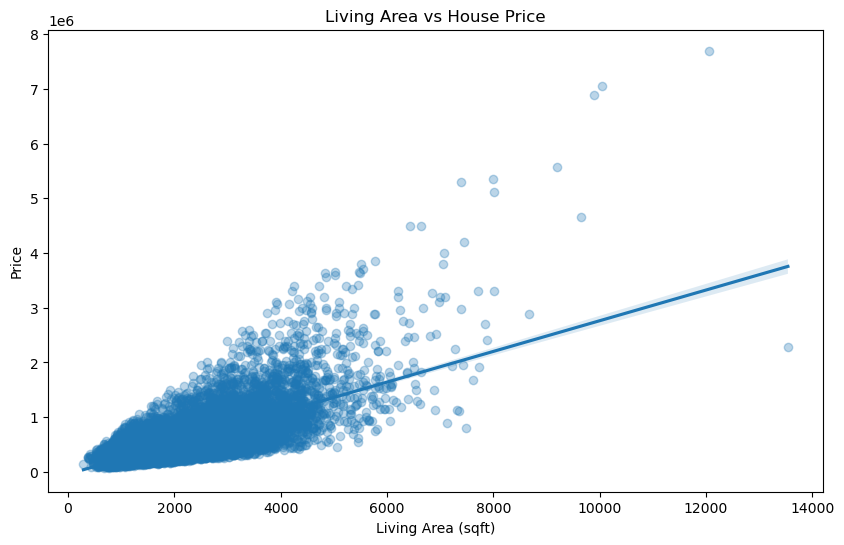

In [22]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="sqft_living",
    y="price",
    scatter_kws={"alpha": 0.3}
)

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")

plt.show()

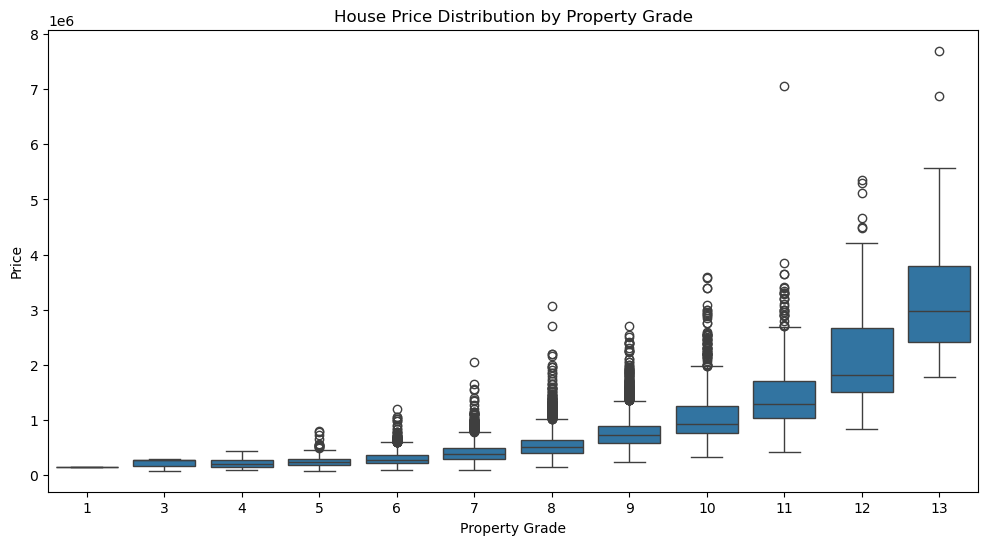

In [6]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="grade",
    y="price"
)

plt.title("House Price Distribution by Property Grade")
plt.xlabel("Property Grade")
plt.ylabel("Price")

plt.show()

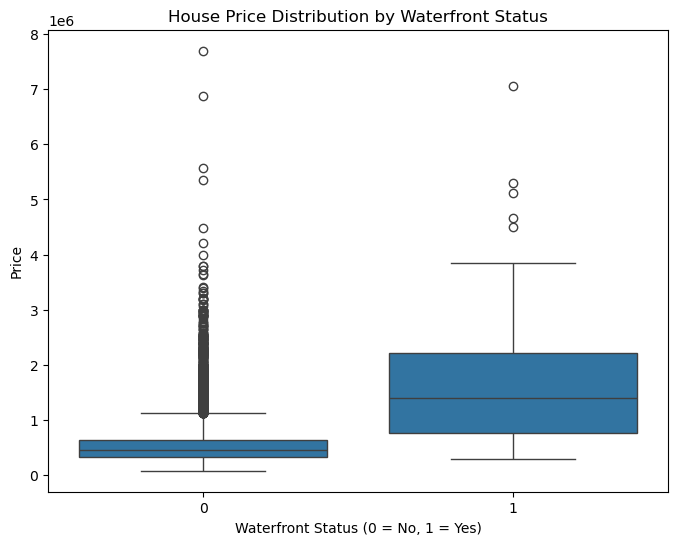

In [8]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="waterfront",
    y="price"
)

plt.title("House Price Distribution by Waterfront Status")
plt.xlabel("Waterfront Status (0 = No, 1 = Yes)")
plt.ylabel("Price")

plt.show()

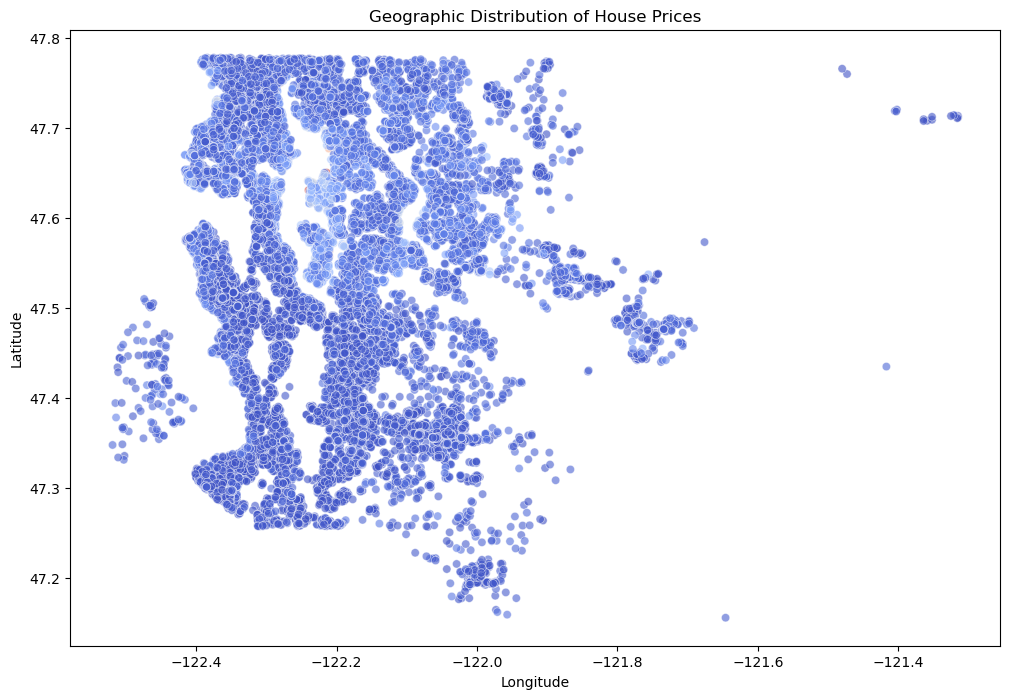

In [10]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="long",
    y="lat",
    hue="price",
    palette="coolwarm",
    alpha=0.6,
    legend=False
)

plt.title("Geographic Distribution of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [12]:
location_summary = df.groupby("zipcode")["price"].agg(
    ["count", "mean", "median", "max"]
).reset_index()

location_summary = location_summary.sort_values(
    by="mean",
    ascending=False
)

location_summary.head(10)

,zipcode,count,mean,median,max
24,98039,50,2.160607e+06,1892500.0,6885000.0
3,98004,317,1.355927e+06,1150000.0,7062500.0
25,98040,282,1.194230e+06,993750.0,5300000.0
48,98112,269,1.095499e+06,915000.0,3400000.0
41,98102,105,9.012583e+05,720000.0,7700000.0
47,98109,109,8.796236e+05,736000.0,3200000.0
43,98105,229,8.628252e+05,675000.0,3650000.0
5,98006,498,8.596848e+05,760184.5,4208000.0
53,98119,184,8.494480e+05,744975.0,3065000.0
4,98005,168,8.101649e+05,765475.0,1960000.0


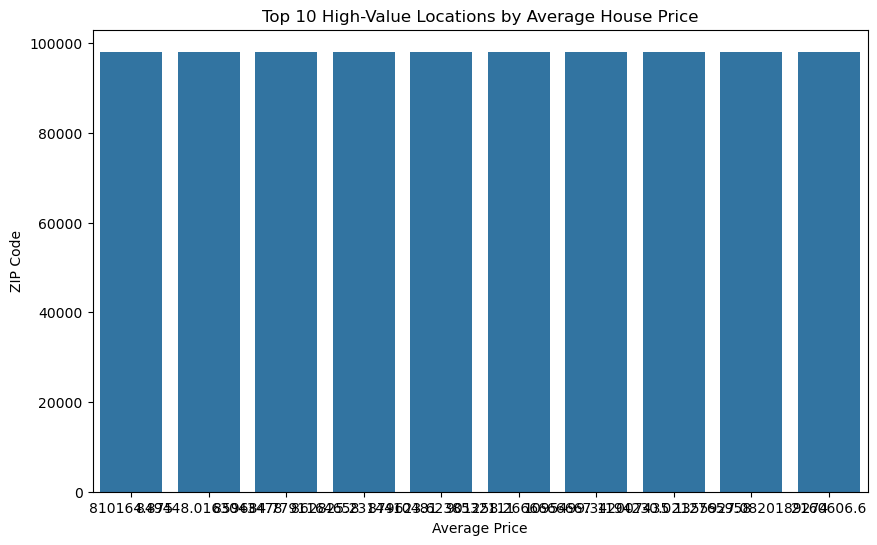

In [14]:
top_locations = location_summary.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_locations,
    x="mean",
    y="zipcode"
)

plt.title("Top 10 High-Value Locations by Average House Price")
plt.xlabel("Average Price")
plt.ylabel("ZIP Code")

plt.show()

In [18]:
top_10 = location_summary.head(10)

print("REAL ESTATE INVESTMENT SUMMARY REPORT")
print("-" * 50)

print("\nTotal Properties:", len(df))
print("Average House Price:", round(df["price"].mean(), 2))
print("Median House Price:", round(df["price"].median(), 2))

print("\nTOP 10 HIGH-VALUE LOCATION CLUSTERS")
print(top_10[["zipcode", "count", "mean", "median", "max"]])

print("\nINVESTMENT INSIGHTS")
print("-" * 50)



REAL ESTATE INVESTMENT SUMMARY REPORT
--------------------------------------------------

Total Properties: 21613
Average House Price: 540088.14
Median House Price: 450000.0

TOP 10 HIGH-VALUE LOCATION CLUSTERS
    zipcode  count          mean     median        max
24    98039     50  2.160607e+06  1892500.0  6885000.0
3     98004    317  1.355927e+06  1150000.0  7062500.0
25    98040    282  1.194230e+06   993750.0  5300000.0
48    98112    269  1.095499e+06   915000.0  3400000.0
41    98102    105  9.012583e+05   720000.0  7700000.0
47    98109    109  8.796236e+05   736000.0  3200000.0
43    98105    229  8.628252e+05   675000.0  3650000.0
5     98006    498  8.596848e+05   760184.5  4208000.0
53    98119    184  8.494480e+05   744975.0  3065000.0
4     98005    168  8.101649e+05   765475.0  1960000.0

INVESTMENT INSIGHTS
--------------------------------------------------
